In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


DATASET LOADED
Shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  defa

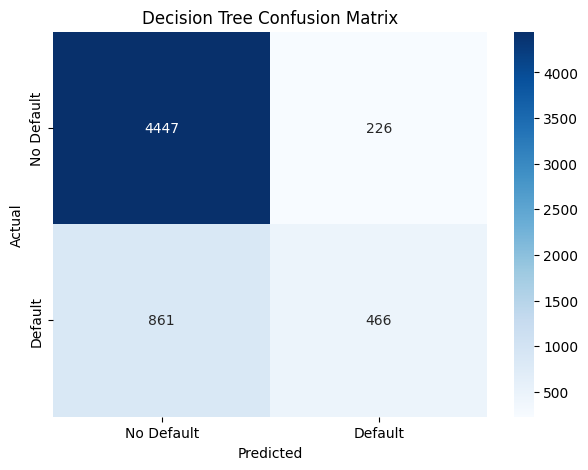


FEATURE IMPORTANCE
             Feature  Importance
               PAY_0    0.660087
NUM_DELAYED_PAYMENTS    0.215080
   TOTAL_PAYMENT_AMT    0.033319
  PAYMENT_BILL_RATIO    0.020751
           LIMIT_BAL    0.014408
            PAY_AMT2    0.005989
        AVG_BILL_AMT    0.005567
                 AGE    0.005318
            PAY_AMT3    0.005292
AVG_REPAYMENT_STATUS    0.004682
               PAY_6    0.004556
               PAY_2    0.003940
           BILL_AMT2    0.003708
                  ID    0.003486
               PAY_4    0.003082


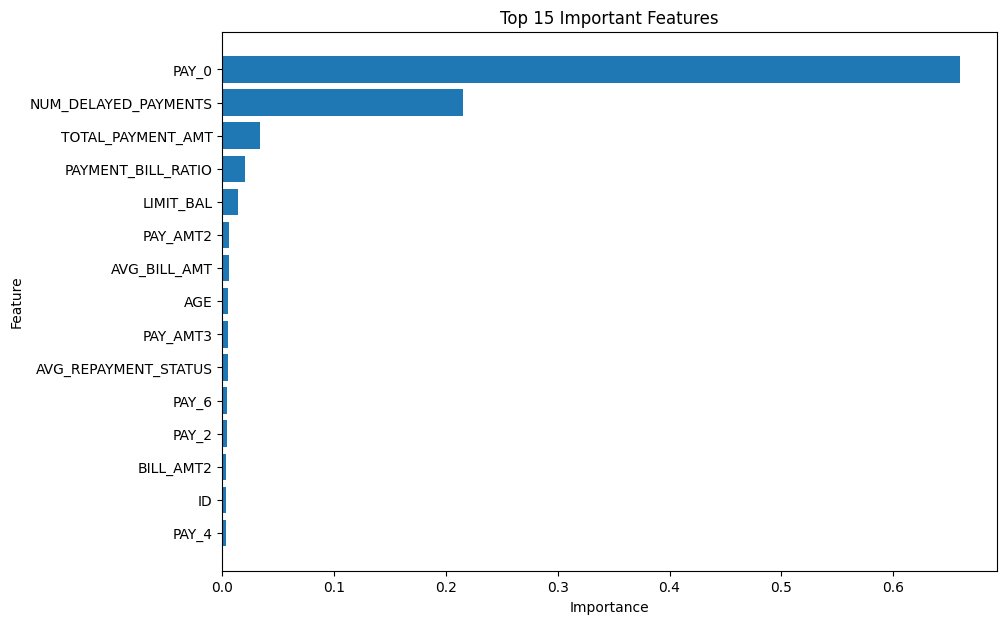

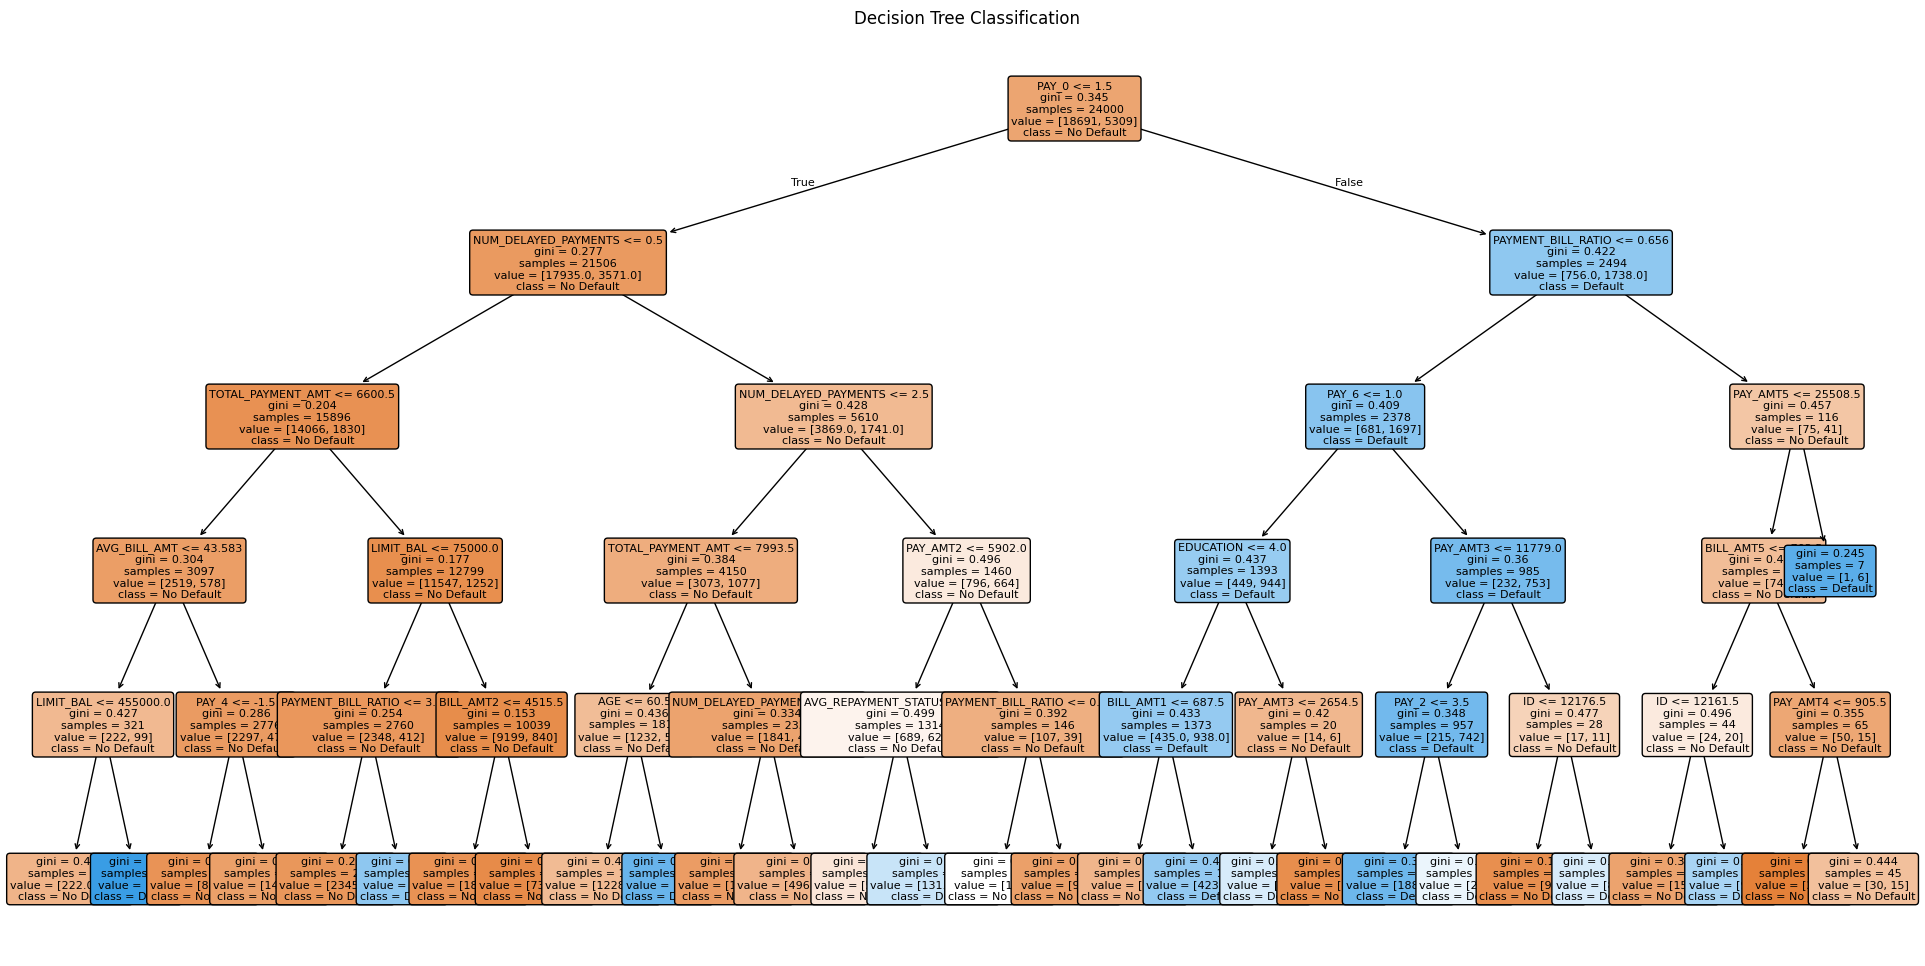


SAMPLE CUSTOMER PREDICTION
Prediction: No Default
Actual Class: 0

Prediction Probabilities:
No Default: 0.8527
Default: 0.1473

DECISION TREE INFORMATION
Tree Depth: 5
Number of Leaves: 29

PROJECT SUMMARY
Dataset                : UCI Credit Card Dataset
Target                 : default.payment.next.month
Algorithm              : Decision Tree Classifier
Criterion              : Gini
Maximum Depth          : 5
Training/Test Split    : 80/20
Accuracy               : 0.8188
Precision              : 0.6734
Recall                 : 0.3512
F1 Score               : 0.4616


In [ ]:

# DECISION TREE CLASSIFICATION PROJECT
# Dataset: UCI_Credit_Card.csv

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# -------------------- 2. LOAD DATASET ------------------------

df = pd.read_csv("UCI_Credit_Card.csv")

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


# -------------------- 3. BASIC EDA ----------------------------

print("\n" + "=" * 60)
print("BASIC EDA")
print("=" * 60)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


# -------------------- 4. REMOVE DUPLICATES --------------------

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


# -------------------- 5. DEFINE TARGET ------------------------

# Target:
# 0 = Customer does NOT default
# 1 = Customer defaults

target = "default.payment.next.month"

X = df.drop(columns=[target])
y = df[target]

print("\nTarget Distribution:")
print(y.value_counts())


# -------------------- 6. FEATURE ENGINEERING ------------------

# Total bill amount
df["TOTAL_BILL_AMT"] = (
    df["BILL_AMT1"] +
    df["BILL_AMT2"] +
    df["BILL_AMT3"] +
    df["BILL_AMT4"] +
    df["BILL_AMT5"] +
    df["BILL_AMT6"]
)

# Average bill amount
df["AVG_BILL_AMT"] = df[
    [
        "BILL_AMT1",
        "BILL_AMT2",
        "BILL_AMT3",
        "BILL_AMT4",
        "BILL_AMT5",
        "BILL_AMT6"
    ]
].mean(axis=1)

# Total payment amount
df["TOTAL_PAYMENT_AMT"] = (
    df["PAY_AMT1"] +
    df["PAY_AMT2"] +
    df["PAY_AMT3"] +
    df["PAY_AMT4"] +
    df["PAY_AMT5"] +
    df["PAY_AMT6"]
)

# Average payment amount
df["AVG_PAYMENT_AMT"] = df[
    [
        "PAY_AMT1",
        "PAY_AMT2",
        "PAY_AMT3",
        "PAY_AMT4",
        "PAY_AMT5",
        "PAY_AMT6"
    ]
].mean(axis=1)

# Payment-to-bill ratio
df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)

# Average repayment status
df["AVG_REPAYMENT_STATUS"] = df[
    [
        "PAY_0",
        "PAY_2",
        "PAY_3",
        "PAY_4",
        "PAY_5",
        "PAY_6"
    ]
].mean(axis=1)

# Number of delayed payments
df["NUM_DELAYED_PAYMENTS"] = (
    df[
        [
            "PAY_0",
            "PAY_2",
            "PAY_3",
            "PAY_4",
            "PAY_5",
            "PAY_6"
        ]
    ] > 0
).sum(axis=1)


# -------------------- 7. CREATE AGE GROUP ---------------------

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior",
        "Older"
    ]
)


# -------------------- 8. UPDATE X AND Y ------------------------

X = df.drop(columns=[target])
y = df[target]


# -------------------- 9. ENCODE AGE GROUP ----------------------

# Decision Trees need numerical input.
# Convert AGE_GROUP into dummy variables.

X = pd.get_dummies(
    X,
    columns=["AGE_GROUP"],
    drop_first=True
)


# -------------------- 10. HANDLE MISSING VALUES ---------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(X.median(numeric_only=True))

# Make sure all remaining columns are numerical
X = X.astype(float)


print("\nFinal Feature Shape:", X.shape)


# -------------------- 11. TRAIN TEST SPLIT ---------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


# -------------------- 12. CREATE DECISION TREE -----------------

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


# -------------------- 13. TRAIN MODEL --------------------------

model.fit(X_train, y_train)

print("\nDecision Tree trained successfully!")


# -------------------- 14. MAKE PREDICTIONS ---------------------

y_pred = model.predict(X_test)


# -------------------- 15. MODEL EVALUATION ---------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# -------------------- 16. CLASSIFICATION REPORT ---------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Default",
            "Default"
        ],
        zero_division=0
    )
)


# -------------------- 17. CONFUSION MATRIX ---------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Default",
        "Default"
    ],
    yticklabels=[
        "No Default",
        "Default"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()


# -------------------- 18. FEATURE IMPORTANCE -------------------

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance_df.head(15).to_string(index=False))


# -------------------- 19. FEATURE IMPORTANCE GRAPH -------------

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()


# -------------------- 20. VISUALIZE DECISION TREE --------------

plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "No Default",
        "Default"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classification")

plt.show()


# -------------------- 21. SAMPLE CUSTOMER PREDICTION -----------

sample_customer = X_test.iloc[[0]]

sample_prediction = model.predict(
    sample_customer
)

print("\n" + "=" * 60)
print("SAMPLE CUSTOMER PREDICTION")
print("=" * 60)

if sample_prediction[0] == 0:
    print("Prediction: No Default")
else:
    print("Prediction: Default")

print("Actual Class:", y_test.iloc[0])


# -------------------- 22. PREDICTION PROBABILITY --------------

sample_probability = model.predict_proba(
    sample_customer
)

print("\nPrediction Probabilities:")

print(
    "No Default:",
    round(sample_probability[0][0], 4)
)

print(
    "Default:",
    round(sample_probability[0][1], 4)
)


# -------------------- 23. TREE INFORMATION ---------------------

print("\n" + "=" * 60)
print("DECISION TREE INFORMATION")
print("=" * 60)

print("Tree Depth:", model.get_depth())

print("Number of Leaves:", model.get_n_leaves())


# -------------------- 24. FINAL SUMMARY ------------------------

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("Dataset                : UCI Credit Card Dataset")
print("Target                 : default.payment.next.month")
print("Algorithm              : Decision Tree Classifier")
print("Criterion              : Gini")
print("Maximum Depth          :", model.max_depth)
print("Training/Test Split    : 80/20")
print("Accuracy               :", round(accuracy, 4))
print("Precision              :", round(precision, 4))
print("Recall                 :", round(recall, 4))
print("F1 Score               :", round(f1, 4))
